# 01 · Data, target and benchmark

**Question.** Using only open ECMWF weather forecasts, can we predict tomorrow's hourly GB wind generation as well as NESO's own forecast (WINDFOR), issued at the same moment?

Window: 2024-03-16 → 2024-12-31 (291 days, 6,984 hours). Anything fitted is fitted on Mar–Jul and scored on Aug–Dec. The 2025+ test window is not loaded.

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from windpfn import baselines, data, dataset, figures, sites

A, B = "2024-03-16", "2024-12-31"
d = baselines.add(dataset.build(A, B).set_index("valid_time"))
price = dataset.hourly(data.prices("2024-03-09", B)).reindex(d.index)
test = d[d.index >= baselines.SPLIT]

## 1 · When the forecast is made
Every day D-1 we forecast the 24 hours of day D. We issue 15 min after NESO publishes its morning WINDFOR vintage (08:30 UTC in summer, 07:30 in winter), so both forecasts are made with the same information cutoff. The weather run must have been public before WINDFOR was.

In summer that is the ECMWF 00Z run of D-1. In winter, the 00Z run (public ~07:55) is 25 min too late, so we use the 18Z run of D-2, which is 6 h older.

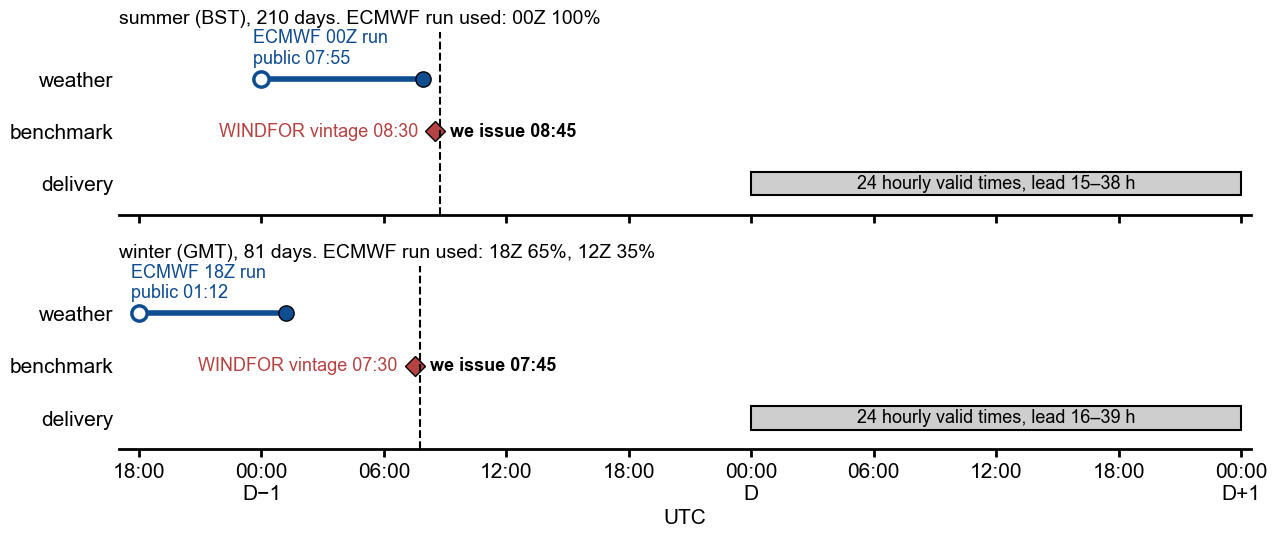

In [2]:
figures.timeline(d);

## 2 · Data in

| source | what | resolution | used as |
|---|---|---|---|
| ECMWF IFS open data | 100 m wind speed at 20 points | 0.25°, 3-hourly → hourly | **features** |
| Elexon BM unit list + B1610 | installed metered wind capacity | weekly | **feature** |
| NESO WINDFOR | NESO's wind forecast, 8 vintages/day | hourly | **benchmark** (and a feature in claim b) |
| Elexon FUELHH | metered wind output | half-hourly | **target**, part 1 |
| Elexon BOAV | wind that NESO paid to switch off (curtailment) | half-hourly | **target**, part 2 |

The 20 points are capacity-weighted clusters of GB wind farms (REPD, ≥10 MW): 10 offshore, 10 onshore.

c:\Users\Csome\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Csome\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Csome\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Csome\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

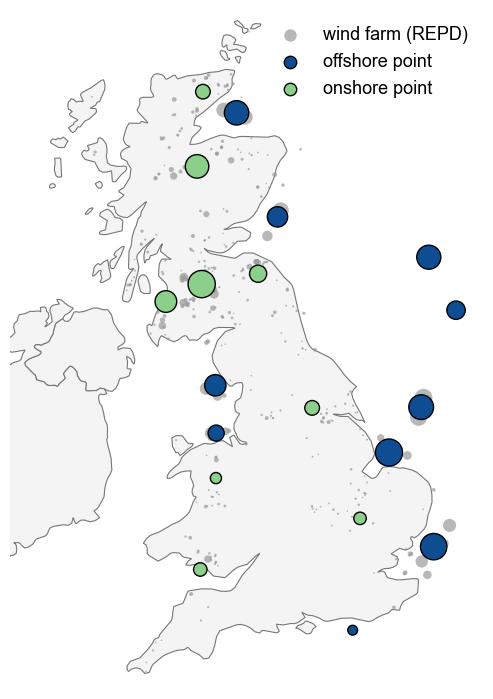

In [3]:
figures.sites_map(*sites.clusters());

## 3 · What the model sees
One row per delivery hour. Each column except `y` is known at issue time; `dataset.check` asserts this.
- **features:** `ws_*` wind speed at 20 points (m/s), `cap` installed capacity (MW), `lead_h`, `hour`, `doy_sin`, `doy_cos`
- **benchmark:** `windfor` (MW); claim (b) also gives it to the model as a feature
- **target:** `y`, available wind (MW), defined in §4

In [4]:
d[dataset.FEATURES + ["windfor", "y"]].iloc[[0, 12]].T.round(1)

valid_time,2024-03-16 00:00:00+00:00,2024-03-16 12:00:00+00:00
ws_off_00,10.9,2.3
ws_off_01,8.7,1.7
ws_off_02,3.7,9.4
ws_off_03,13.9,6.3
ws_off_04,10.6,1.9
ws_off_05,8.3,3.1
ws_off_06,11.6,3.9
ws_off_07,13.2,6.7
ws_off_08,8.3,4.3
ws_off_09,5.8,8.5


## 4 · The target: what WINDFOR forecasts
On windy days the grid between Scotland and England fills up, and NESO pays Scottish farms to switch off. Metered output then falls short of what the wind could have produced.

WINDFOR is an *input* to that decision, so it should forecast output **before** curtailment. The data confirms this: against metered output WINDFOR looks biased high, but once curtailment is added back the two sit on the diagonal (a). Regressing WINDFOR on the two parts gives almost equal weights. So the target is **`y` = metered + curtailed**.

WINDFOR ≈ 0.95·metered + 0.90·curtailed + 653 MW
curtailment: 58% of hours, 12% of available energy
negative-price hours: 3.2%; WINDFOR − y there: +596 MW, elsewhere: +188 MW


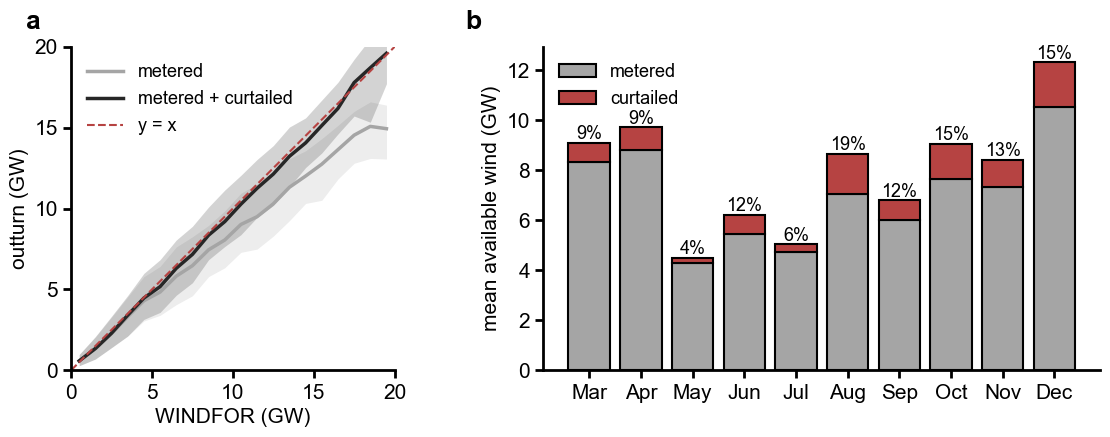

In [5]:
figures.target(d)
r = LinearRegression().fit(d[["y_metered", "curtailed"]], d.windfor)
print(f"WINDFOR ≈ {r.coef_[0]:.2f}·metered + {r.coef_[1]:.2f}·curtailed + {r.intercept_:.0f} MW")
print(f"curtailment: {(d.curtailed > 50).mean():.0%} of hours, {d.curtailed.sum() / d.y.sum():.0%} of available energy")
neg = price < 0
print(f"negative-price hours: {neg.mean():.1%}; WINDFOR − y there: {(d.windfor - d.y)[neg].mean():+.0f} MW, elsewhere: {(d.windfor - d.y)[~neg].mean():+.0f} MW")

## 5 · Assumptions that change the data

| | assumption | effect |
|---|---|---|
| 1 | Target adds curtailment back (§4) | +12% energy; changes 58% of hours |
| 2 | Only wind metered by the grid operator (~25 of ~32 GW). Small embedded farms are invisible nationally | Same scope for target and WINDFOR, so the comparison is fair; not total GB wind |
| 3 | Farms that turn themselves down at negative prices are not added back: this is not recorded as curtailment | In the 3% of hours with negative prices, WINDFOR sits ~600 MW above `y` (vs ~190 MW elsewhere) |
| 4 | Hourly value at t = mean of the two half-hours ending at t | Other alignments change MAE by <3% |
| 5 | Weather = nearest 0.25° grid cell to each point; 3-hourly steps interpolated linearly | Smooths short ramps |
| 6 | Only runs public before WINDFOR; if the run is missing on the Google mirror, the next older one | 25 days (16 in March, 9 in November) use a 12Z run 6 h older than needed |
| 7 | Point locations come from the 2026 farm list | Includes a few farms built after 2024; the model learns point weights, so the effect is small |
| 8 | Capacity = today's nameplate, counted from each unit's first metered output + 7 d | Tracks new farms (23.3 → 25.5 GW in 2024); ignores outages |

## 6 · The benchmark to beat
Two reference forecasts, scored on Aug–Dec:
- **WINDFOR:** NESO's operational forecast.
- **Power curve:** the simplest physics model. A generic turbine curve turns each point's wind speed into a capacity factor, and one non-negative weight per point (fitted Mar–Jul) combines them. This is what open weather alone gets you without any learning beyond 20 weights.

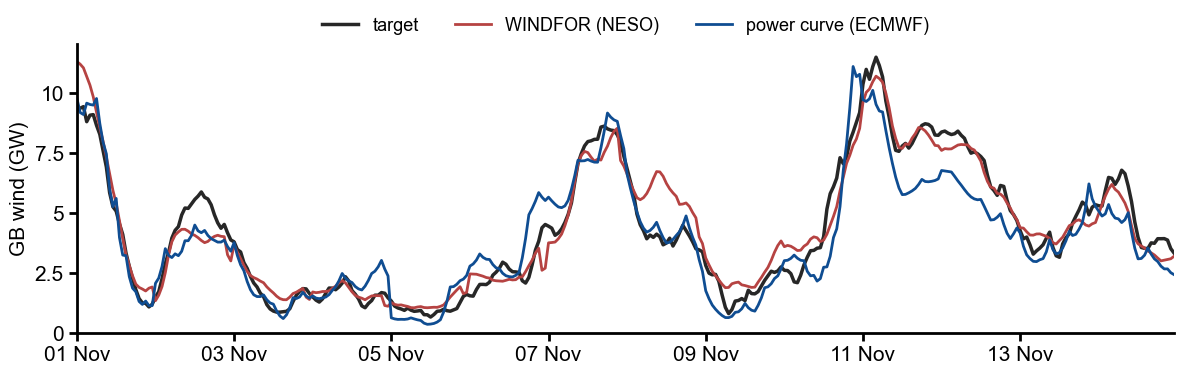

In [6]:
figures.week(d);

,windfor,powercurve,blend
MAE (MW),929.0,975.0,811.0


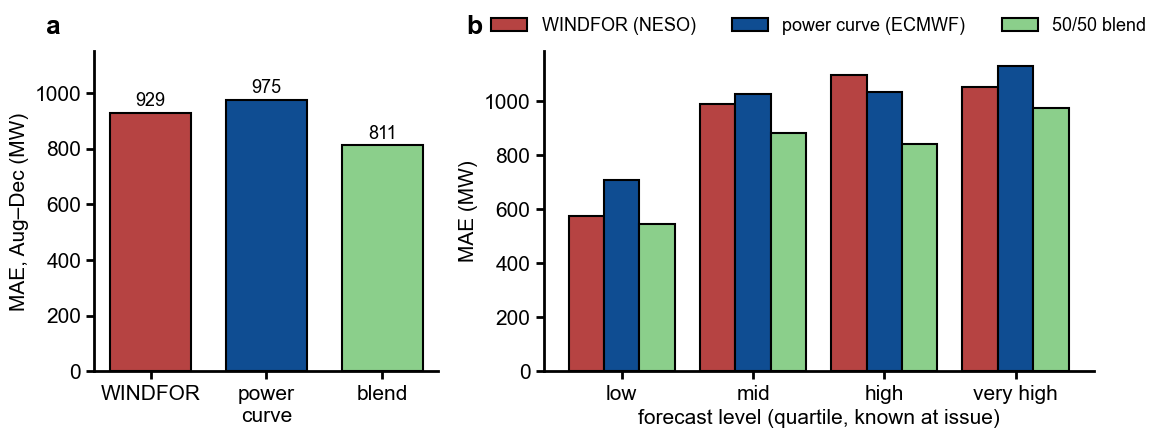

In [7]:
figures.benchmarks(d)
pd.Series({m: figures.MAE(test, m) for m in figures.NAME}).round(0).rename("MAE (MW)").to_frame().T

WINDFOR beats the power curve by 5%. Yet their errors are only moderately correlated, so a plain 50/50 average beats both by 13%, at every forecast level (b). That sets two bars for the model:
- **(a) weather only:** beat WINDFOR, **929 MW**.
- **(b) weather + WINDFOR as a feature:** beat the 50/50 blend, **811 MW**.

## 7 · What the errors look like
- **(a)** Error spread grows with output, so uncertainty must depend on the forecast level: a fixed ± band would be wrong.
- **(b)** Error grows with lead time. WINDFOR's edge is at short leads, where it has fresher inputs than our run.
- **(c)** Errors persist for hours, so 6,984 hours carry far less information than it seems: significance tests must resample whole days.

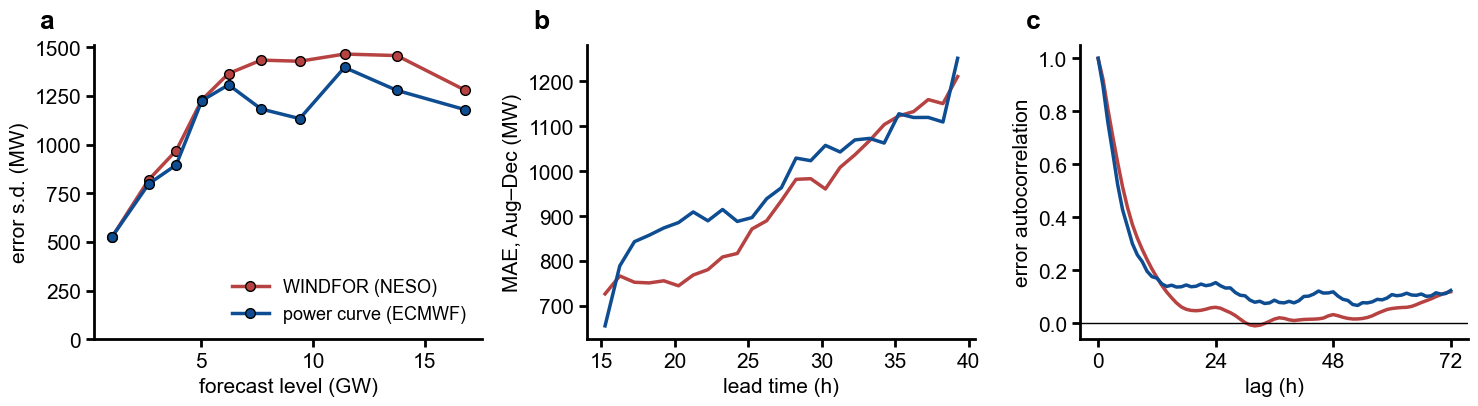

In [8]:
figures.errors(d);